In [ ]:
# Notebook to show useful Prefect features for data engineering and data science workflows.
%pip install prefect

# Step 2: Running the Tool
- Create hello_prefect.py python script with some basic @task and @flow functions
- Run the file (python hello_prefect.py) and the workflow should run and the temp server will then close

- To see the ui run prefect server start
- In a different terminal, run the python script again and see the new run appear

# Step 3: Orchestrating the Workflow
- Run a prefect pipeline with original python script and mlflow logging.
- We use the functions from duration_prediction.py and wrap them in prefect tasks and a flow. 
- Run the prefect server with, prefect server start
- The duration_prediction.py has 
  - mlflow.set_tracking_uri("http://localhost:5000")
  - mlflow.set_experiment("nyc-taxi-experiment")
  - So we need to use mlflow ui --backend-store-uri sqlite:////workspaces/mlops-zoomcamp/03-orchestration/mlflow_data/mlflow.db
- We should now have mlflow running on http://127.0.0.1:5000/ and prefect running on another port, e.g. http://127.0.0.1:4200
- Finally, in a new terminal run python prefect_duration_pred.py --year 2023 --month 1

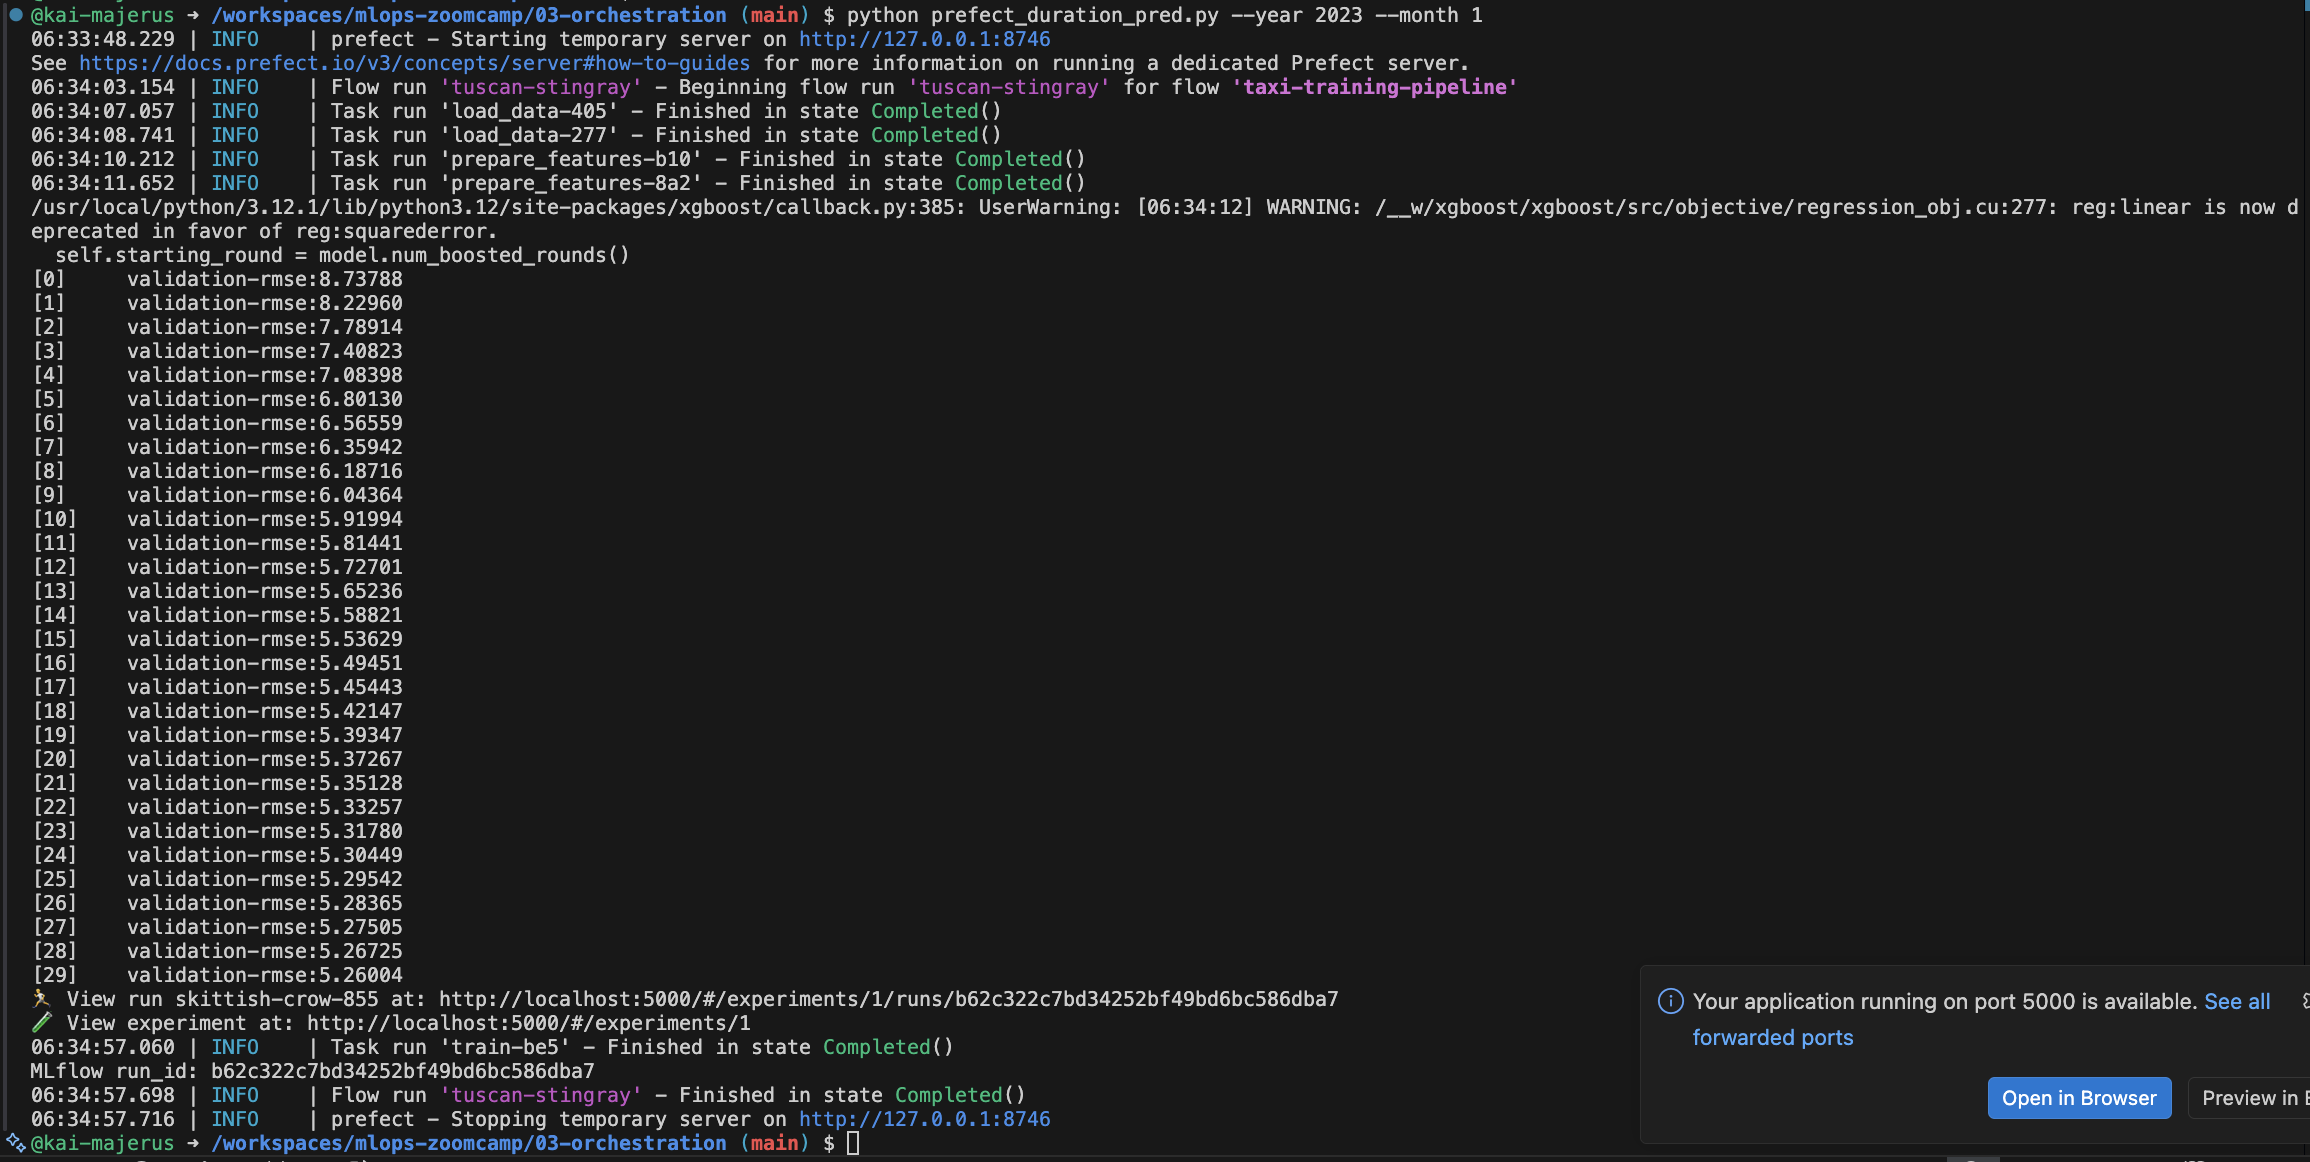

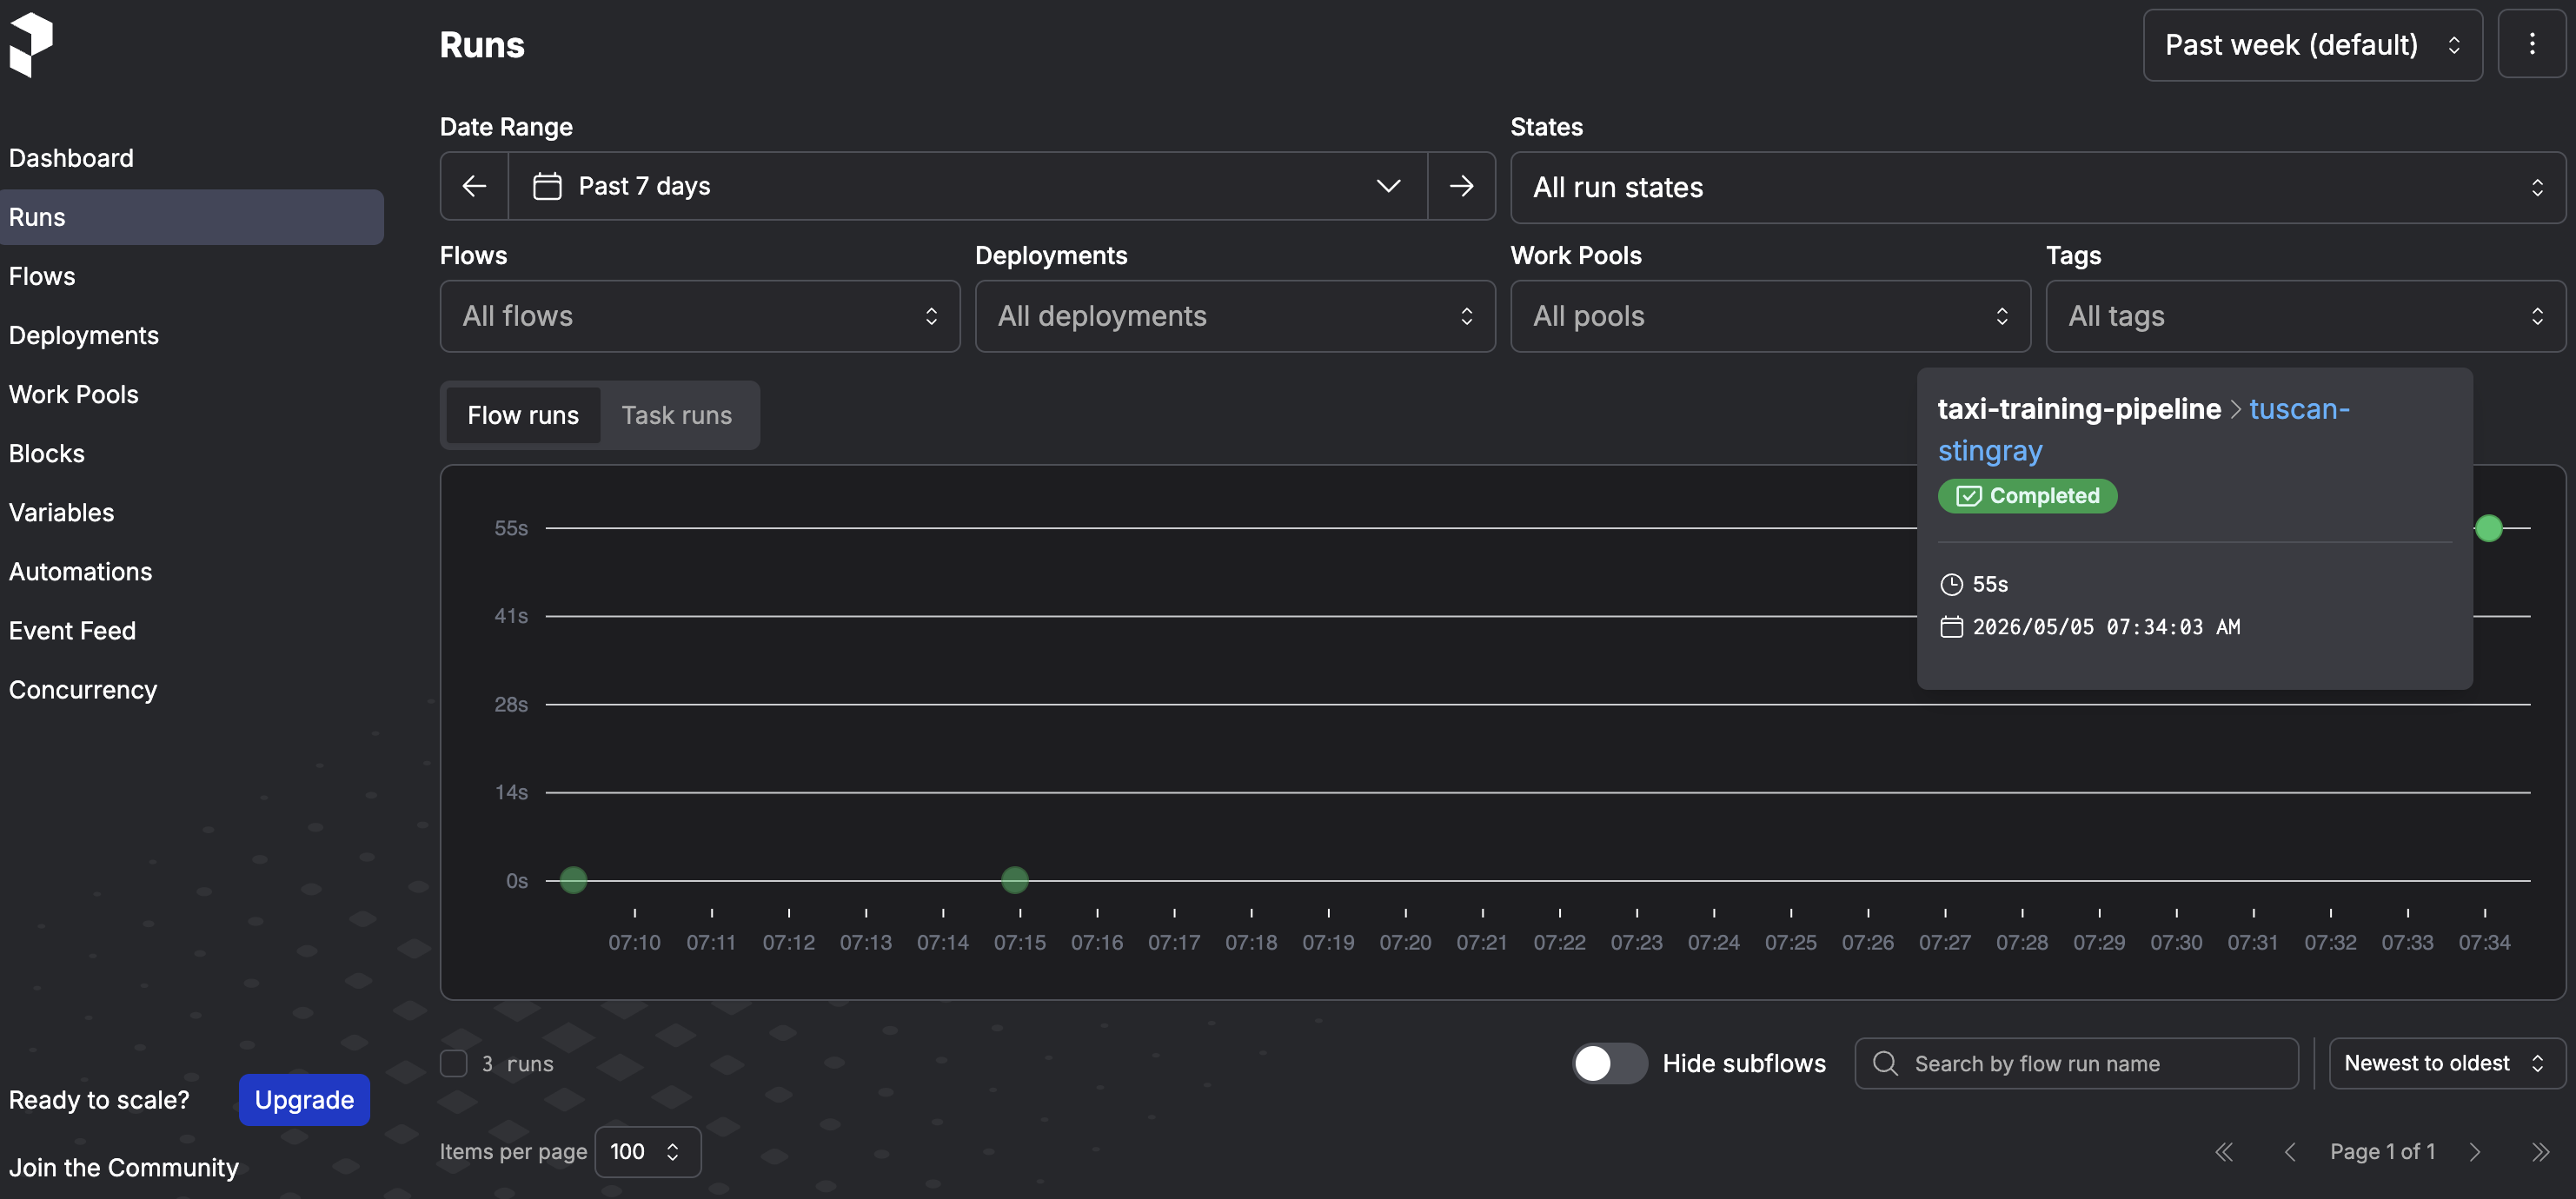

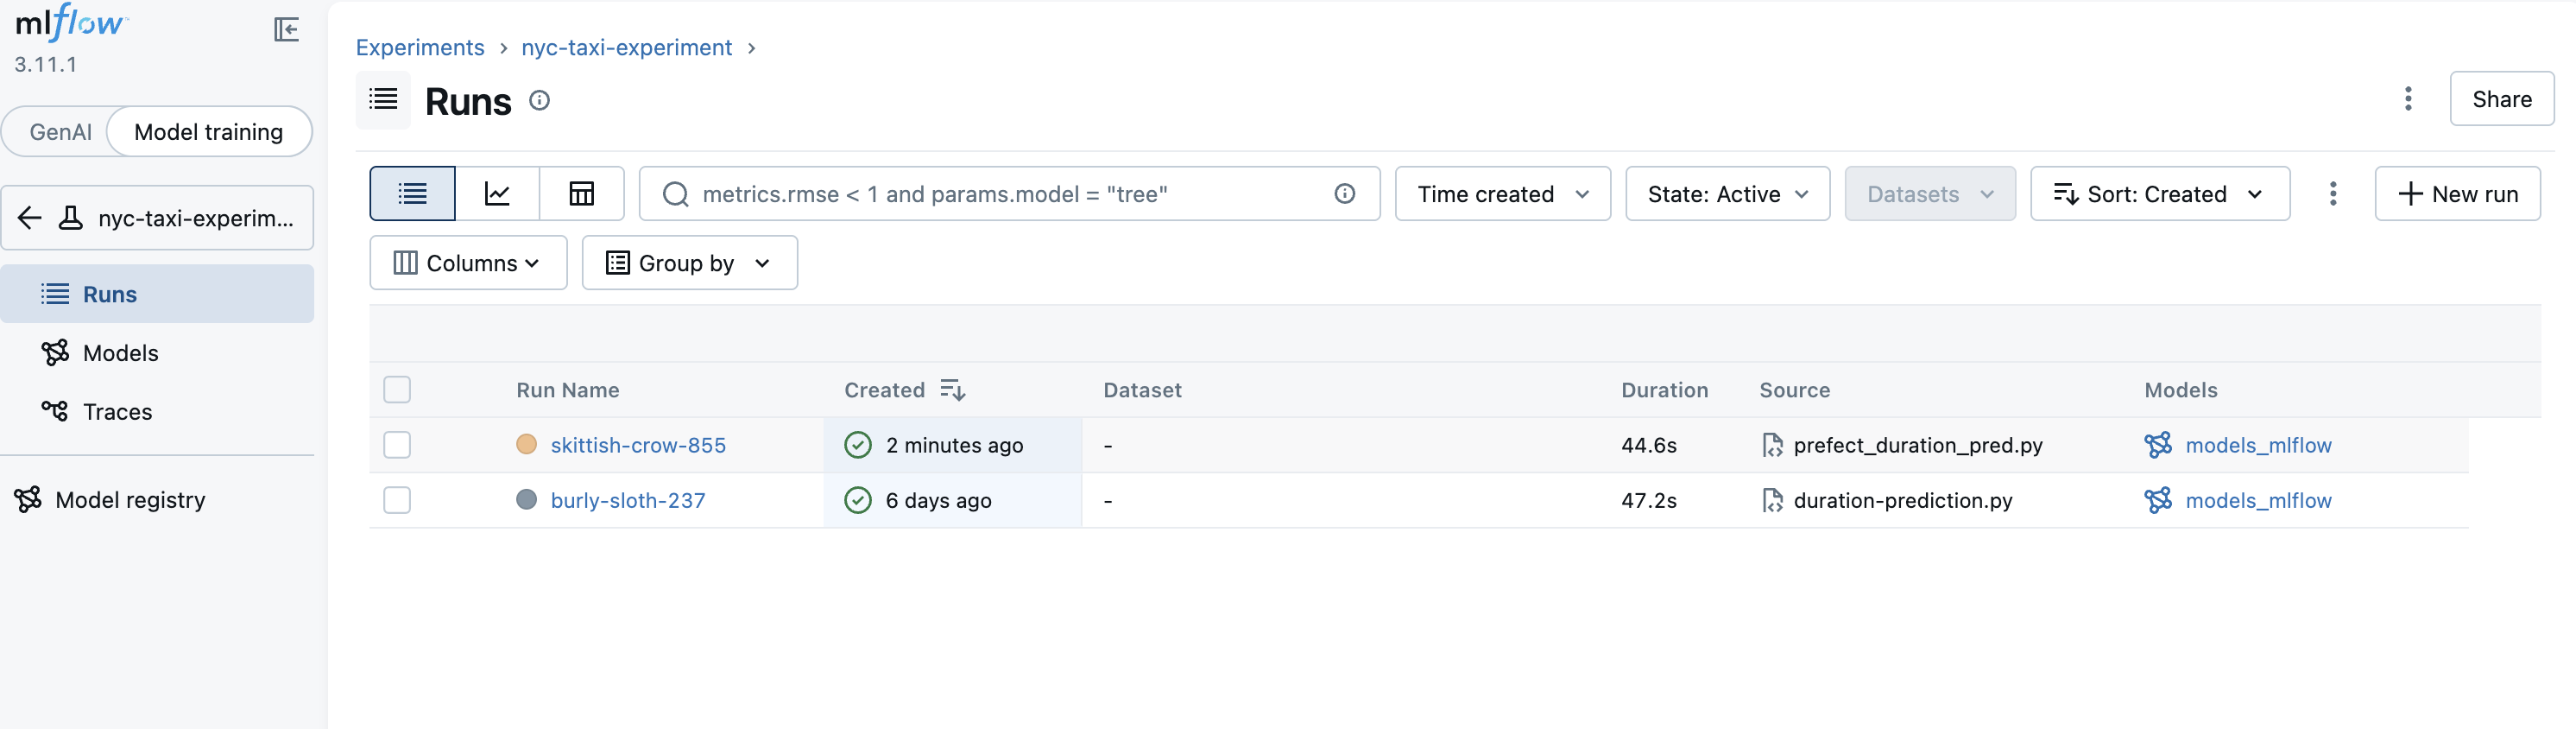

# Step 4: Parametrizing the Workflow
  - Schedule the workflow to run monthly
  - The train data should be from two months ago
  - The validation data - one month ago

  
- Instead of inputting year and month, we can change the flow to calculate 2 months ago for the training data and 1 month ago for validation data
- Then we run python prefect_duration_pred.py

# Step 5: Localy deployment and scheduling (this is not in the cloud, still requires local server to be running)

- Add year and month back in as inputs. If No year or month is given, then it will run the default schedule.
- Otherwise, we can provide year and month (useful for backfilling)

- Setup a simple deployment by adding .serve() to the main block of the file

taxi_training_pipeline.serve(name='my-first-deployment')

- This starts a process listening for scheduled runs. You can now trigger the flow from the Prefect UI or programmatically.


- Now schedule it to run every day at 08:10am 

taxi_training_pipeline.serve(
            name="my-first-deployment",
            cron="10 8 * * *"
        )

Your workflow will now run automatically according to the schedule while the serve process is running.

So we need 3 things: 

## Error prone - will try the cloud setup next time

- Terminal 1: prefect server start
- Terminal 2: 
  - export PREFECT_API_URL=http://127.0.0.1:4200/api
  - prefect work-pool create default-agent-pool --type process  # only once
  - prefect worker start --pool default-agent-pool
- Terminal 3: 
  - export PREFECT_API_URL=http://127.0.0.1:4200/api
  - python prefect_duration_pred.py --serve


Then we can run mlflow later. If we run it at the same time as prefect, prefect server will stop since both are trying to use sql alchemy
- mlflow ui --backend-store-uri sqlite:////workspaces/mlops-zoomcamp/03-orchestration/mlflow_data/mlflow.db 

# Cloud 